# State Vector Representation

In [18]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import array_to_latex, plot_histogram
from fractions import Fraction
import numpy as np
from numpy import sqrt

## Definition
Quantum state vectors are defined by 2 properties:
1. Entries are complex numbers (can be negative)
2. Euclidean norm is 1 (sum of the squares of the entries is 1)

In [2]:
u = Statevector([1 / sqrt(2), 1 / sqrt(2)]) # valid
v = Statevector([(1 + 2j) / 3, (-2)/3]) # valid
w = Statevector([1, 1]) # invalid, euclidean norm is not 1

display(u.draw('latex'))
display(v.draw('latex'))
display(w.draw('latex'))

print('Is u a valid state vector?', u.is_valid())
print('Is v a valid state vector?', v.is_valid())
print('Is w a valid state vector?', w.is_valid())

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Is u a valid state vector? True
Is v a valid state vector? True
Is w a valid state vector? False


|0⟩ and |1⟩ are the standard basis vectors for a single qubit, and any state vector can be represented as a linear combination of these basis vectors.
Thus we call quantum state vectors to be *superpositions* of the basis vectors (notice *u* and *v* from above are such superpositions)

Additionally, 2 other common quantum state vectors are the plus (|+⟩) and minus (|-⟩) states which are defined below:

In [3]:
ket0 = Statevector([1, 0]) # or .from_label('0')
ket1 = Statevector.from_label('1')

plus = Statevector([1 / sqrt(2), 1 / sqrt(2)]) # or .from_label('+')
minus = Statevector.from_label('-')

display(ket0.draw('latex', prefix="|0\\rangle = "))
display(ket1.draw('latex', prefix="|1\\rangle = "))
display(plus.draw('latex', prefix="|+\\rangle = "))
display(minus.draw('latex', prefix="|-\\rangle = "))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

**NOTE**: The |0⟩ entry is never negative, this is due to the irrelvance of the global phase, which is discussed further in [???](./quantum-circuits.ipynb).

## Matrix Products in Quantum Context
When multiplying bra-kets in a classical setting (for example, ⟨0|1⟩), we take the inner product of the two vectors, which results in a scalar value. In this case, ⟨0|1⟩ = 0, since the two vectors are orthogonal.

However in quantum, we must take the conjugate-transpose of the second vector (ket). The reason for this is described later in [???](./quantum-circuits.ipynb).

In [4]:
psi = Statevector([(1 + 2j) / 3, (-2) / 3])
display(psi.draw('latex', prefix="|\\psi\\rangle = "))

ket0 = Statevector.from_label('0')
display(ket0.draw('latex'))

res = ket0.inner(psi)
res = np.array([res])
display(array_to_latex(res, prefix="\\langle 0 | \\psi \\rangle = "))



<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

A quantum state is not limited to a superposition of the 2 basis vectors, can have 3 or more vectors, although the 2 standard basis vectors are the most common.

In [5]:
state1 = Statevector([1 / 2, (-1j) / 2, 1 / sqrt(2)]) # valid with euclidean norm
display(state1.draw('latex'))
print('Is state1 a valid state vector?', state1.is_valid())

state2 = Statevector([(1 + 2j) / 3, -2 / 3, 5]) # invalid, euclidean norm is not 1
display(state2.draw('latex'))
print('Is state2 a valid state vector?', state2.is_valid())

<IPython.core.display.Latex object>

Is state1 a valid state vector? True


<IPython.core.display.Latex object>

Is state2 a valid state vector? False


## Measurement of State Vectors
When we measure a quantum state vector, we collapse it to one of the basis states. The probability of collapsing to a particular basis state is given by the square of the magnitude of the coefficient of that basis state in the superposition.

In [17]:
plus = Statevector.from_label('+')
display(plus.draw('latex', prefix="|+\\rangle = "))

# notice that the output probabilities are the squares of the amplitudes, and they sum to 1
print("Probability of measuring |0> in state |+>:", Fraction(plus.probabilities_dict()['0']).limit_denominator())
print("Probability of measuring |1> in state |+>:", Fraction(plus.probabilities_dict()['1']).limit_denominator())

# notice that the minus state probabilites are the same as the plus state, as the sign does not affect the probabilities
minus = Statevector.from_label('-')
display(minus.draw('latex', prefix="|-\\rangle = "))

print("Probability of measuring |0> in state |->:", Fraction(minus.probabilities_dict()['0']).limit_denominator())
print("Probability of measuring |1> in state |->:", Fraction(minus.probabilities_dict()['1']).limit_denominator())

phi = Statevector([(1+ 2j)/3, -2/3])
display(phi.draw('latex', prefix="|\\phi\\rangle = "))

print("Probability of measuring |0> in state |\\phi>:", Fraction(phi.probabilities_dict()['0']).limit_denominator())
print("Probability of measuring |1> in state |\\phi>:", Fraction(phi.probabilities_dict()['1']).limit_denominator())

<IPython.core.display.Latex object>

Probability of measuring |0> in state |+>: 1/2
Probability of measuring |1> in state |+>: 1/2


<IPython.core.display.Latex object>

Probability of measuring |0> in state |->: 1/2
Probability of measuring |1> in state |->: 1/2


<IPython.core.display.Latex object>

Probability of measuring |0> in state |\phi>: 5/9
Probability of measuring |1> in state |\phi>: 4/9


You can test the probabilities experimentally by running repeated measurements on the same state vector:

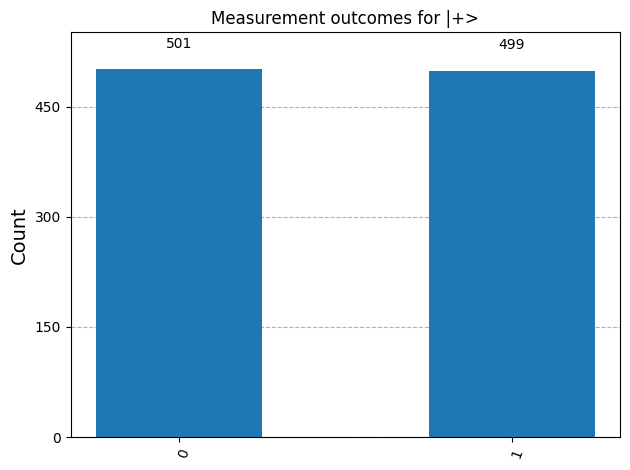

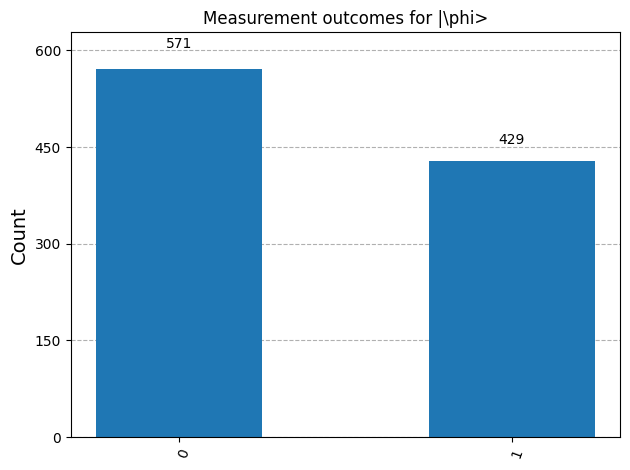

In [28]:
plus = Statevector.from_label('+')
display(plot_histogram(data=plus.sample_counts(1000), title="Measurement outcomes for |+>"))

phi = Statevector([(1+ 2j)/3, -2/3])
display(plot_histogram(data=phi.sample_counts(1000), title="Measurement outcomes for |\\phi>"))